In [9]:
import matplotlib.pyplot as plt
from matplotlib import pyplot
import matplotlib.dates as mdates
from matplotlib.colors import to_hex

import numpy as np
import json
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from os import walk

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mutexa.rollingAvePlots import initialization

pyplot.rcParams['figure.dpi'] = 600
pyplot.rcParams['savefig.dpi'] = 600


In [2]:
def initialization(csvfile):
    countryGrouping = pd.read_csv(csvfile)
    countryGrouping = countryGrouping[['Sub-region Name', 'Country or Area']]
    country2region = {}
    for index, row in countryGrouping.iterrows():
        country2region[row.iloc[1]] = row.iloc[0]
    country2region['USA'] = 'Northern America'
    country2region['Taiwan'] = 'Eastern Asia'
    country2region['Hong Kong'] = 'Eastern Asia'
    country2region['United Kingdom'] = 'Northern Europe'
    country2region['South Korea'] = 'Eastern Asia'
    country2region['Vietnam'] = 'South-eastern Asia'
    country2region['Iran'] = 'Southern Asia'
    country2region['Czech Republic'] = 'Eastern Europe'
    country2region['Russia'] = 'Eastern Europe'
    country2region['Crimea'] = 'Eastern Europe'
    country2region['Brunei'] = 'South-eastern Asia'
    country2region['\u200eRomania'] = 'Eastern Europe'
    country2region['Venezuela'] = 'Latin America'
    country2region['Moldova'] = 'Eastern Europe'
    country2region['Reunion'] = 'Eastern Africa'
    country2region['Curacao'] = 'Latin America'
    country2region['Republic of Congo'] = 'Sub-Saharan Africa'
    country2region['Palestine'] = 'Western Asia'
    country2region['Saint Barthélemy'] = 'Latin America and the Caribbean'
    country2region['Saint Martin'] = 'Latin America and the Caribbean'
    country2region['CotedIvoire'] = 'Sub-Saharan Africa'
    country2region['Czech Repubic'] = 'Eastern Europe'
    country2region['St Eustatius'] = 'Latin America and the Caribbean'
    countryGrouping = pd.DataFrame.from_dict(country2region, orient='index')
    countryGrouping.columns = ['Region']
    countryGrouping.index.names = ['Country']
    return country2region, countryGrouping


In [3]:
path = 'mpxv_country_ms10-1.2/'
filenames = next(walk(path), (None, None, []))[2]  # [] if no file
print(filenames)

['MPXV_country_min10_G91046A1.2_heatmapmatrix.json', 'MPXV_country_min10_ratioData.csv', 'MPXV_country_min10_Heatmaps_mut:A22R_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mut:T36032C_t:1.2.jpeg', 'MPXV_country_min10_Heatmaps_mut:A152435-_t:1.2.jpeg', 'MPXV_country_min10_Heatmaps_mut:T144857A_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mutF8L_t1.2.csv', 'MPXV_country_min10_RollingAvg_mut:G91852T_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mut:A22R_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mutG33133A_t1.2.csv', 'MPXV_country_min10_RollingAvg_mutT73309C_t1.2.csv', 'MPXV_country_min10_RollingAvg_mut:F8L_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mut:T74490A_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mutA152435-_t1.2.csv', '.DS_Store', 'MPXV_country_min10_Heatmaps_mut:G91852T_t:1.2.jpeg', 'MPXV_country_min10_RollingAvg_mutT74384C_t1.2.csv', 'MPXV_country_min10_RollingAvg_mutG91852T_t1.2.csv', 'MPXV_country_min10_T173050G1.2_heatmapmatrix.json', 'MPXV_country_min10_Heatmaps_mut:T74490A_t

In [61]:
# Data
#path = 'mpxv_country_ms10-1.2/'
prefix = 'fluAHA'
group_name = 'country'
group = 'E391K'
threshold = 1.2
with open('fluAHAcountry_2024data_E391K1.2_heatmapmatrix.json', 'r') as file:
#with open('outputs/' + prefix + '_' + m  + '_' + userColumn + str(threshold) + '_heatmapmatrix.json', 'r') as file:
    data = json.load(file)
heatmap = pd.DataFrame(data['z'], index=data['y'], columns=data['x'])

country2region, countryGrouping = initialization("UNSD — Methodology.csv")
country2region, countryGrouping 

if group_name == 'country':
    heatmap['Region'] = heatmap.index.map(country2region)
    heatmap = heatmap.sort_values(['Region'])
    heatmap = heatmap.drop(['Region'], axis=1)
else:
    heatmap = heatmap.sort_index()

lineplot = pd.read_csv('fluAHAcountry_2024data_RollingAvg_mutE391K_t1.2.csv')
#lineplot = pd.read_csv('outputs/' + prefix + '_' + m  + '_' + userColumn + str(threshold) + '_RollingAve.csv')
line_melted = lineplot.melt(id_vars='Date', value_vars=lineplot.columns[1:], 
                    var_name=group_name, value_name='Value').sort_values(group_name)

line_melted['Date'] = pd.to_datetime(line_melted['Date'])
heatmap.columns = pd.to_datetime(heatmap.columns)
line_melted= line_melted.sort_values([group_name, 'Date']).reset_index(drop=True)
line_melted

,Date,country,Value
0,2009-01-01,Canada,NaN
1,2009-01-02,Canada,NaN
2,2009-01-03,Canada,NaN
3,2009-01-04,Canada,NaN
4,2009-01-05,Canada,NaN
...,...,...,...
7295,2010-12-27,United Kingdom,56.0
7296,2010-12-28,United Kingdom,50.0
7297,2010-12-29,United Kingdom,47.0
7298,2010-12-30,United Kingdom,35.0


['#b15928', '#ffff99', '#6a3d9a', '#ff7f00', '#fdbf6f', '#e31a1c', '#33a02c', '#b2df8a', '#1f78b4', '#a6cee3']


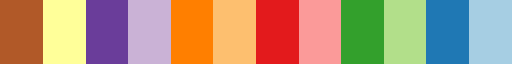

In [5]:
#Colour palette, max 10 categories to show
#from pypalettes import load_cmap, load_palette
#n = len(line_melted[group_name].unique())
n = 10
#cmap = load_cmap("Classic_Cyclic")
#palette = [to_hex(cmap(i / (n - 1))) for i in range(n)]
#palette

#OR use default
cmap = plt.get_cmap('Paired_r')
palette = [to_hex(cmap(i / (n - 1))) for i in range(n)]
print(palette)
cmap

#palette = ['#b15928', '#ffff99', '#6a3d9a', '#ff7f00', '#fdbf6f', '#e31a1c', '#33a02c', '#b2df8a', '#1f78b4', '#a6cee3']

In [62]:
# Nested labels: Country only or provide own dictionary
from matplotlib.patches import FancyArrowPatch
from collections import defaultdict

# group countries by continent preserving heatmap row order
from collections import defaultdict
continent_groups = defaultdict(list)
for i, country in enumerate(heatmap.index):
    continent_groups[country2region[country]].append(i)

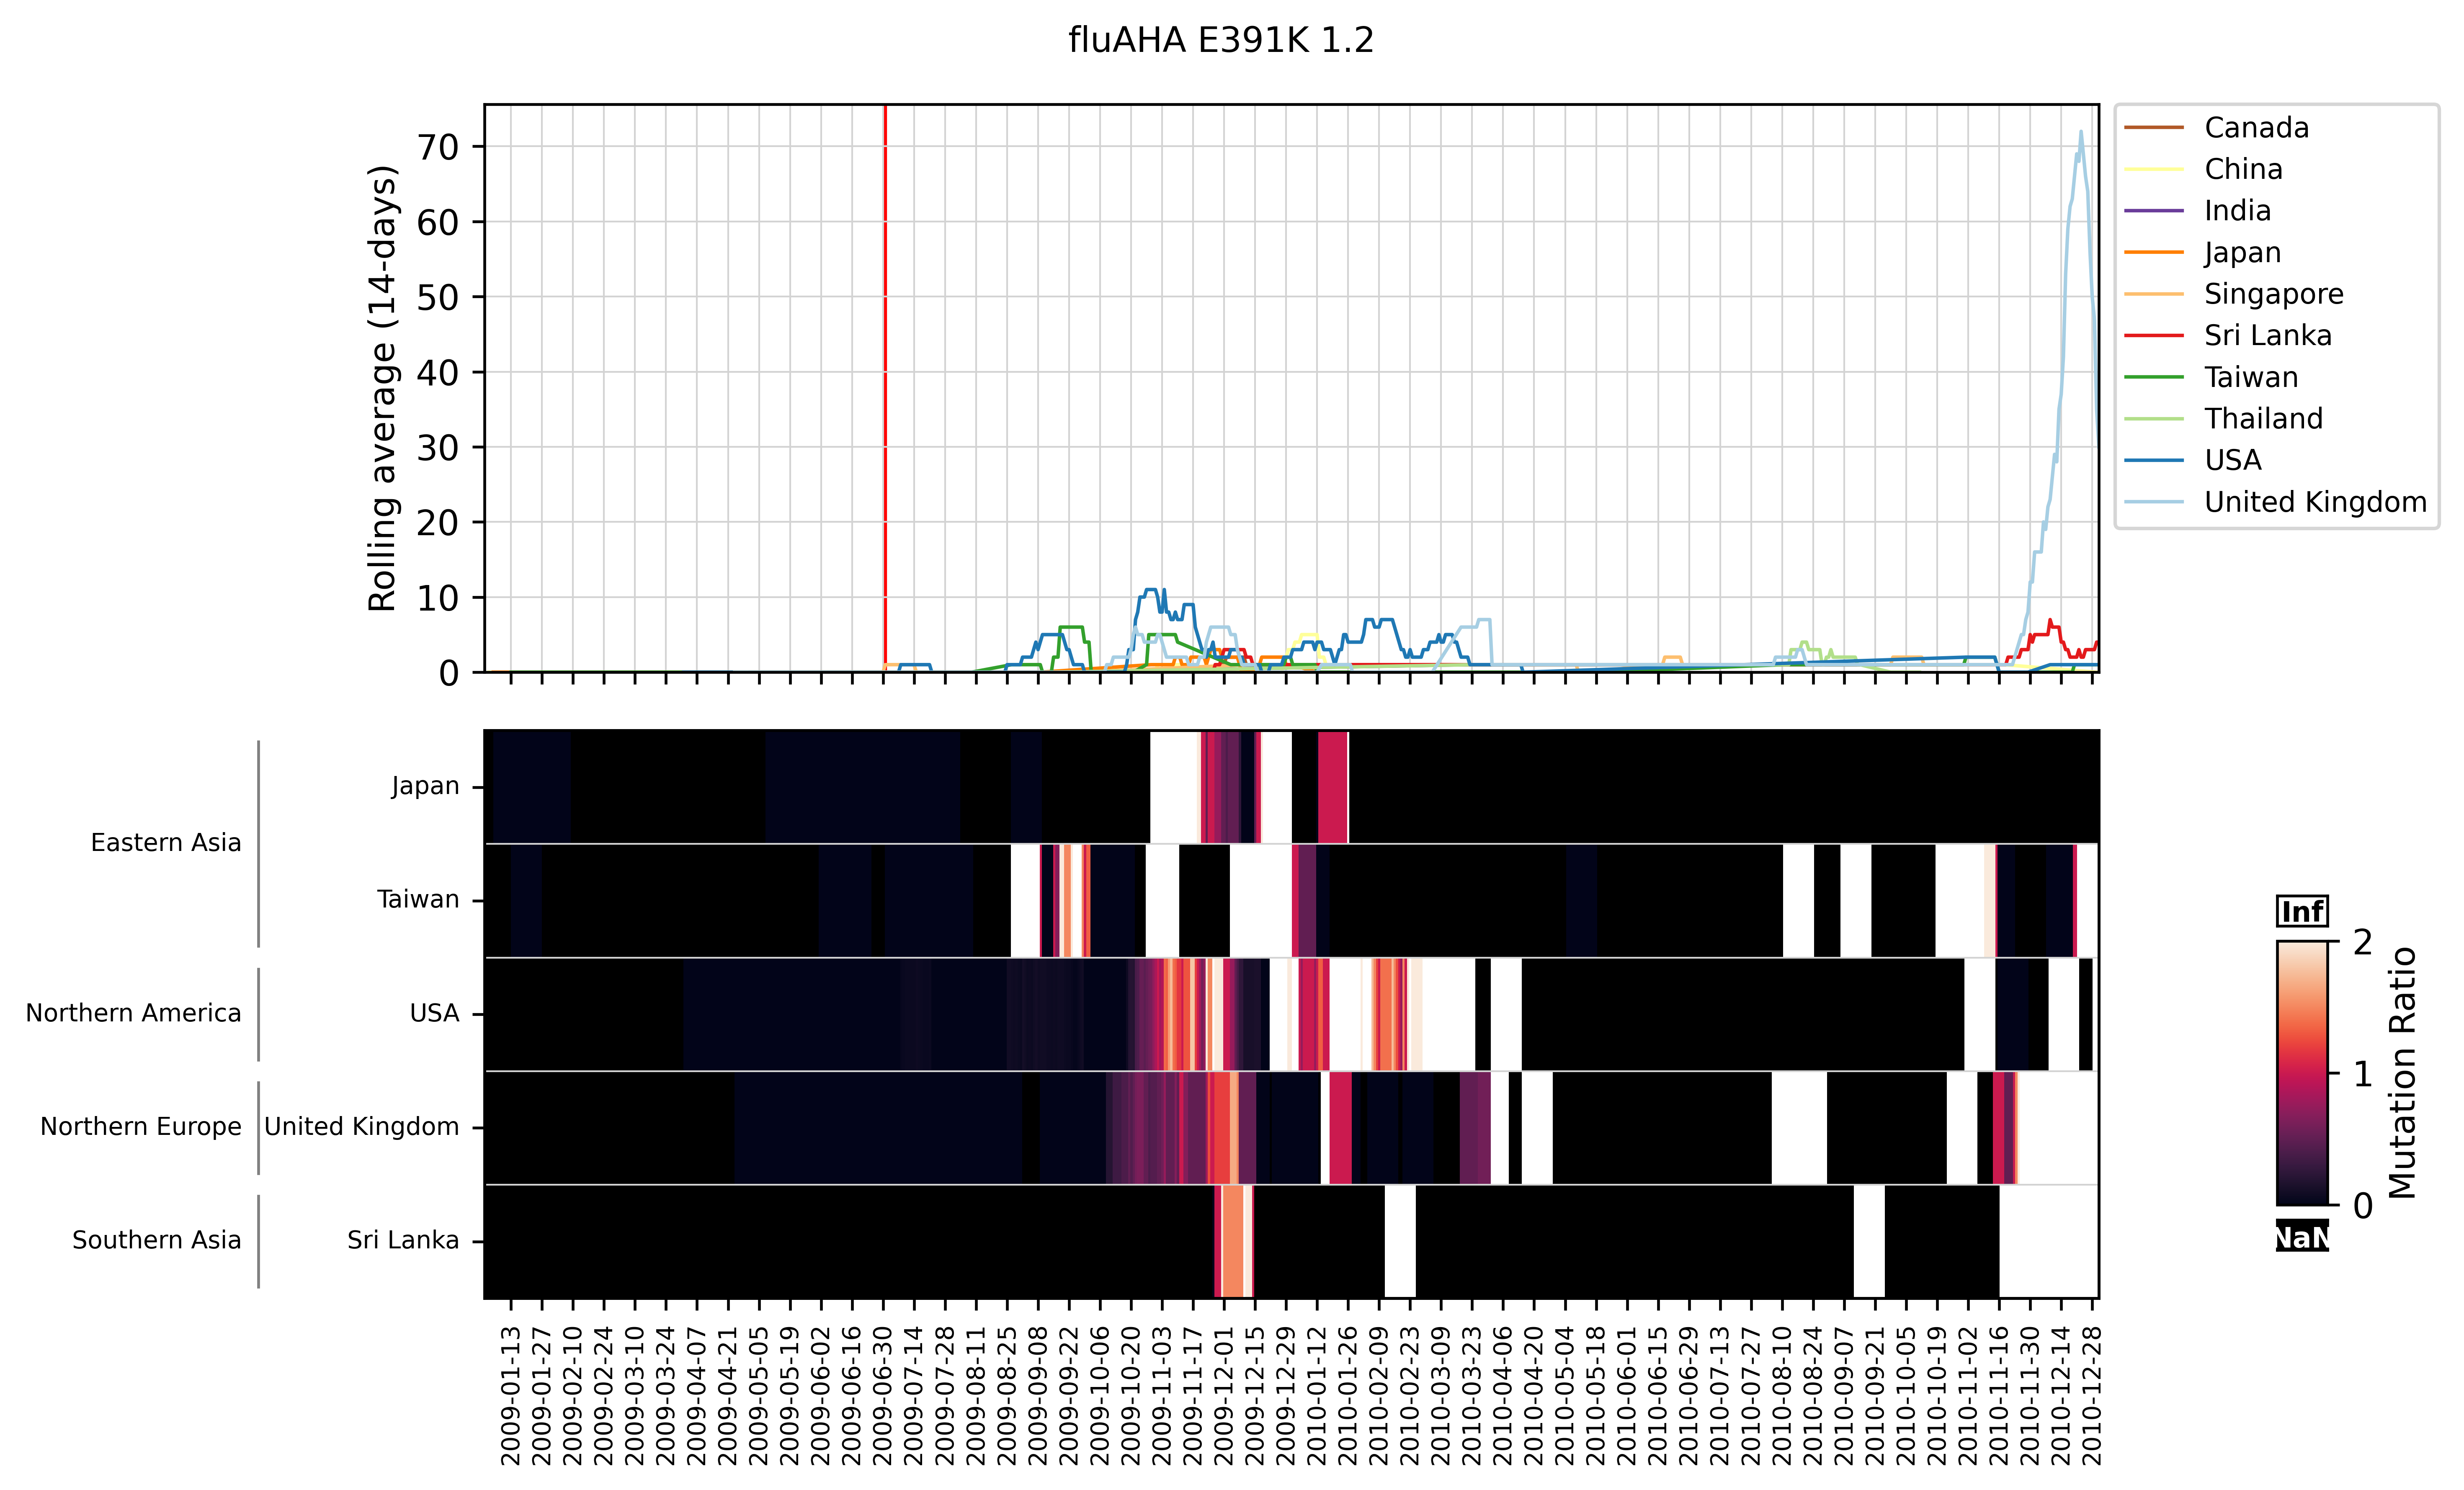

In [63]:
axis_fontsize=7
title_fontsize =10 
interval=2 # Weeks to display for each tick

# Change height ratios to adjust subplot sizes and heights
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True,gridspec_kw={'height_ratios': [0.05, len(heatmap)*0.01]})
# Manual gridlines
axes[0].set_facecolor("white")
axes[0].grid(True, which="major", axis="y", color="lightgrey", linestyle="-", linewidth=0.5)
axes[0].grid(True, which="major", axis="x", color="lightgrey", linestyle="-", linewidth=0.5)

# after all axes[1] plotting code, add back heatmap background
axes[1].set_facecolor("black")
axes[1].grid(False)
axes[1].xaxis.grid(False)
axes[1].yaxis.grid(False)

# re-add separator line
for i in range(1, len(heatmap.index)):
    axes[1].axhline(y=i, color='lightgrey', linewidth=0.5)

#MinDate
minD= line_melted.loc[line_melted["Value"].astype(float) > 0]
mindate = minD.Date.min().date()
mindate

#Line plot
sns.lineplot(data=line_melted, linewidth=1,x='Date', y='Value', hue=group_name, ax=axes[0], palette=palette)
axes[0].set_ylabel("Rolling average (14-days)")
axes[0].tick_params(labelsize=10)
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=interval))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].set_ylim(bottom=0)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,fontsize=8)
axes[0].axvspan(*mdates.datestr2num([str(mindate),str(mindate)]), color = 'red')

# heatmap with datetime axis
import matplotlib.dates as mdates
xmin = mdates.date2num(pd.to_datetime(heatmap.columns[0]))
xmax = mdates.date2num(pd.to_datetime(heatmap.columns[-1]))
heatmap_plot = heatmap.copy().astype(float)
heatmap_plot.replace([np.inf], 3, inplace=True)  # 3 is above vmax=2

cmap = sns.color_palette("rocket", as_cmap=True)
cmap.set_over('white')  # color for values above vmax (INF box)

im =  axes[1].imshow(heatmap_plot.values, aspect='auto', vmin=0, vmax=2,cmap=cmap,interpolation='none',
               extent=[xmin, xmax, len(heatmap), 0])
axes[1].xaxis_date()
#axes[1].set_yticks(range(len(heatmap.index)))
#axes[1].set_yticklabels(heatmap.index)
axes[1].set_facecolor("black")
axes[1].tick_params(labelsize=axis_fontsize)
axes[1].tick_params(axis='x', labelrotation=90)
axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
axes[1].set_yticklabels(heatmap.index, va='center')

# Heatmap legend
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.15]) #Left, bottom, width, height
#for i in range(1, len(heatmap.index)):
#    axes[1].axhline(y=i, color='w', linewidth=0.5)

# remove extend and handle inf manually
cbar = fig.colorbar(im, cax=cbar_ax)  # no extend
ticks = [0, 0.25, 0.5, 0.75, 1.0]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])

# add square above colorbar
cbar_pos = cbar_ax.get_position()
inf_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y1 + 0.01, 
                        cbar_pos.width, cbar_pos.width])  # square
inf_ax.set_facecolor('white')
inf_ax.set_xticks([])
inf_ax.set_yticks([])
inf_ax.text(0.5, 0.4, 'Inf', ha='center', va='center',
            color='black', fontsize=8, fontweight='bold',
            transform=inf_ax.transAxes)
# NaN square below colorbar
nan_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01,
                        cbar_pos.width, cbar_pos.width])  # square
nan_ax.set_facecolor('black')
nan_ax.set_xticks([])
nan_ax.set_yticks([])
nan_ax.text(0.5, 0.8, 'NaN', ha='center', va='top',
            color='white', fontsize=8, fontweight='bold',
            transform=nan_ax.transAxes)

fig.colorbar(im, cax=cbar_ax)
#pos = axes[1].get_position()
#cbar_ax = fig.add_axes([0.88, pos.y0 + pos.height * 0.25, 0.02, pos.height * 0.5])
cbar.set_label('Mutation Ratio', fontsize=10)
plt.suptitle(prefix + " "+  group + " "+ str(threshold), size=title_fontsize)
pos = axes[1].get_position()
cbar_height = pos.height * 0.5
cbar_bottom = pos.y0 + (pos.height - cbar_height) / 2

#cbar_ax.set_position([0.80, cbar_bottom, 0.02, cbar_height])
cbar_left = pos.x1 + 0.02
cbar_ax.set_position([cbar_left, cbar_bottom, 0.02, cbar_height])

cbar_pos = cbar_ax.get_position()

inf_ax.set_position([cbar_pos.x0, cbar_pos.y1 + 0.01, cbar_pos.width, cbar_pos.width])
nan_ax.set_position([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01, cbar_pos.width, cbar_pos.width])

# Continent axis
# set country labels
axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
axes[1].set_yticklabels(heatmap.index, va='center')

# add continent labels on a secondary y axis
ax2 = axes[1].twinx()
ax2.set_ylim(axes[1].get_ylim())
ax2.set_yticks([])

# Add secondary axis
for cont, rows in continent_groups.items():
    mid = (min(rows) + max(rows) + 1) / 2
    axes[1].text(-0.15, mid, cont,          # increase negative as needed
             transform=axes[1].get_yaxis_transform(),
             va='center', ha='right', fontsize=axis_fontsize)
    pad = 0.1
    axes[1].plot([-0.14, -0.14], [min(rows) + pad, max(rows) + 1 - pad], # and move line as needed
             transform=axes[1].get_yaxis_transform(),
             color='grey', linewidth=0.8, clip_on=False)

plt.subplots_adjust(left=0.2)
plt.tight_layout()

#plt.savefig('prefix + "_" + group + "_" + str(threshold) + '.svg', dpi=600, bbox_inches='tight')
plt.show()


In [98]:
fontsize = 13
xticks_toshow =30
# Plotly version
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.4, 0.6],
    vertical_spacing=0.05,
)
#Line plot
for i, group in enumerate(line_melted[group_name].unique()):
    sub = line_melted[line_melted[group_name] == group]
    fig.add_trace(
        go.Scatter(
            x=sub['Date'], y=sub['Value'],
            mode='lines',
            name=group,
            line=dict(color=palette[i % len(palette)], width=2),
            legendgroup='lineplot',
        ),
        row=1, col=1,
    )

# min date vertical line
fig.add_vline(
    x=pd.Timestamp(mindate).timestamp() * 1000,
    line=dict(color='red', width=1),
    row=1, col=1,
)
fig.update_layout(hovermode="x unified")
#heatmap
heatmap_plot = heatmap.copy().astype(float)
heatmap_plot.replace([np.inf], 3, inplace=True)  # above vmax
heatmap_plot.replace([np.nan], -1, inplace=True)  # below vmin

# country labels and continent brackets
countries = heatmap.index.tolist() # rename variable if needed to your groups

fig.add_trace(
    go.Heatmap(z=heatmap_plot.values,
        x=pd.to_datetime(heatmap.columns),
        y=countries,
        colorscale='Hot',
        zmin=0, zmax=2,
        colorbar=dict(
            title='',
            thickness=15,
            len=0.4,
            y=0.2,
            yanchor='middle',
        ), 
        showscale=True,
        name='',
        hovertemplate='%{y}<br>%{x}<br>Ratio: %{z:.2f}<extra></extra>',
        hoverongaps=False
    ),
    row=2, col=1,
)
fig.add_annotation(
    x=1.1, y=0.2,
    xref='paper', yref='paper',
    text='Mutation Ratio',
    showarrow=False,
    textangle=-90,
    xanchor='center',
    yanchor='middle',
    font=dict(size=fontsize),
)
# row separator lines between groups
for i in range(1, len(countries)):
    fig.add_hline(
        y=i - 0.5,
        line=dict(color='lightgrey', width=0.5),
        row=2, col=1,
    )
# continent/upper level group annotations
max_country_len = max(len(c) for c in countries)
left_margin = max_country_len * 7 + 150  
x_bracket = -(left_margin / 1800)         # bracket line x in paper coords
x_text = x_bracket - 0.02            # label just left of bracket

for cont, rows in continent_groups.items(): # Secondary label
    mid = (min(rows) + max(rows)) / 2
    top = min(rows) - 0.4 # adjust bracket
    bot = max(rows) + 0.4
    #print(cont, rows)
    # continent label
    fig.add_annotation(
        x=x_text, y=mid,
        xref='paper', yref='y2',
        text=cont,
        showarrow=False,
        xanchor='right',
        font=dict(size=fontsize-2),
    )
    # bracket line
    fig.add_shape(
        type='line',
        x0=x_bracket, x1=x_bracket,
        y0=top, y1=bot,
        xref='paper', yref='y2',
        line=dict(color='grey', width=1),
    )

# Heatmap legend
colorbar_x = 1.03
colorbar_top = 0.40
colorbar_bottom = 0.0

fig.add_annotation(
    x=colorbar_x, y=colorbar_top + 0.03,
    xref='paper', yref='paper',
    text='<b>Inf</b>',
    showarrow=False,
    xanchor='left',
    font=dict(size=9, color='black'),
    bgcolor='white',
    bordercolor='black',
    borderwidth=1,
)
fig.add_annotation(
    x=colorbar_x, y=colorbar_bottom - 0.03,
    xref='paper', yref='paper',
    text='<b>NaN</b>',
    showarrow=False,
    xanchor='left',
    font=dict(size=9, color='white'),
    bgcolor='black',
    bordercolor='grey',
    borderwidth=1,
)

fig.update_layout(
    height=700,
    title=dict(
        text=f"{prefix} {group} {threshold}",
        x=0.5,          # centre title
        xanchor='center',
        font=dict(size=14),
    ),  
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=left_margin, r=120),
    legend=dict(
        x=1.02, y=1,
        xanchor='left',
        font=dict(size=fontsize-1),
    ),
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        title='Rolling average (14-days)',
    ),
    yaxis2=dict(showgrid=False),
    xaxis2=dict(tickangle=-90),
)

fig.update_yaxes(autorange='reversed', row=2, col=1)
fig.update_xaxes(tickformat="%d %b %Y",nticks = xticks_toshow,tickfont=dict(size=fontsize-1))

fig.show()
# Ratio of 3 = inf, -1 = Nan